# LTX-2 Video+Audio Generation on AWS Trainium

This notebook demonstrates how to compile and run the [Lightricks LTX-2](https://huggingface.co/Lightricks/LTX-2) 19B-parameter audio-video diffusion model on AWS Trainium using NxDI (NeuronX Distributed Inference).

**What gets compiled for Neuron:**
- DiT transformer backbone (48 blocks, ~6B params) → Neuron TP=4
- Gemma 3-12B text encoder → Neuron TP=4

**What stays on CPU:**
- Video + Audio VAE decoders (~1B params)
- Tokenizer, scheduler, vocoder

**Hardware:** trn2.3xlarge (1 NeuronDevice, 4 logical NeuronCores with LNC=2)

## 0. Prerequisites

Run this notebook on a **trn2.3xlarge** instance with the Deep Learning AMI Neuron (Ubuntu 24.04).

```bash
# Activate the pre-installed Neuron environment
source /opt/aws_neuronx_venv_pytorch_inference_vllm_0_13/bin/activate

# Install diffusers (LTX-2 requires dev version)
pip install git+https://github.com/huggingface/diffusers.git
pip install imageio imageio-ffmpeg ipywidgets

# Upload this package to the instance
# scp -r ltx2-neuron/ ubuntu@<instance-ip>:/home/ubuntu/
```

In [1]:
import gc
import json
import os
import sys
import time

import torch

# Environment variables for Neuron compiler/runtime
os.environ.setdefault("NEURON_FUSE_SOFTMAX", "1")
os.environ.setdefault("NEURON_CUSTOM_SILU", "1")
os.environ.setdefault("NEURON_RT_STOCHASTIC_ROUNDING_EN", "0")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

# Add the src directory to path
# When running as a notebook, use the notebook's directory; when running via nbconvert, use cwd
try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _nb_dir = os.getcwd()
PACKAGE_DIR = os.path.abspath(os.path.join(_nb_dir, "..", "src"))
if not os.path.isdir(PACKAGE_DIR):
    PACKAGE_DIR = os.path.abspath(os.path.join(_nb_dir, "src"))
sys.path.insert(0, PACKAGE_DIR)
print(f"Package dir: {PACKAGE_DIR}")

print(f"PyTorch: {torch.__version__}")
try:
    import torch_neuronx
    print(f"torch-neuronx: {torch_neuronx.__version__}")
except ImportError:
    print("WARNING: torch_neuronx not found. Are you on a Neuron instance?")

Package dir: /home/ubuntu/ltx2-neuron-release/src
PyTorch: 2.9.0+cu128


torch-neuronx: 2.9.0.2.12.22436+0f1dac25


## 1. Configuration

Set the video resolution, frame count, and output directories.

In [2]:
# Video generation settings
HEIGHT, WIDTH, NUM_FRAMES = 384, 512, 25
NUM_STEPS = 8  # Distilled model uses 8 steps
TP_DEGREE = 4  # Tensor parallelism across 4 NeuronCores
SEED = 42

PROMPT = (
    "A golden retriever puppy runs across a sunny green meadow, "
    "its ears flapping in the wind. The camera follows from a low angle. "
    "Birds chirp in the background."
)

# Compiled model directories (persist across reboots if on /home/ubuntu/)
DIT_COMPILE_DIR = "/home/ubuntu/ltx2_nxdi_compiled_1024/"
GEMMA3_COMPILE_DIR = "/home/ubuntu/gemma3_encoder_compiled_1024/"
GEMMA3_SHARDED_DIR = "/home/ubuntu/gemma3_encoder_sharded/"
OUTPUT_DIR = "/home/ubuntu/ltx2_output/"

print(f"Video: {WIDTH}x{HEIGHT}, {NUM_FRAMES} frames, {NUM_STEPS} steps")
print(f"TP degree: {TP_DEGREE}")
print(f"Prompt: {PROMPT[:80]}...")

Video: 512x384, 25 frames, 8 steps
TP degree: 4
Prompt: A golden retriever puppy runs across a sunny green meadow, its ears flapping in ...


## 2. Compile the DiT Transformer Backbone

The DiT backbone is the denoising workhorse — 48 transformer blocks that run 8 times per generation (once per denoising step), doubled with CFG. This is the component that benefits most from Neuron acceleration.

Compilation traces the model with NxDI's SPMD infrastructure and produces a single `model.pt` NEFF file. **First compilation takes ~2 minutes; subsequent runs load from cache.**

In [3]:
from modeling_ltx2 import (
    LTX2BackboneInferenceConfig,
    NeuronLTX2BackboneApplication,
    replace_sdpa_with_bmm,
)
from neuronx_distributed_inference.models.config import NeuronConfig

# Replace SDPA with BMM for Neuron XLA compatibility
replace_sdpa_with_bmm()

# Load transformer config from HuggingFace
from huggingface_hub import hf_hub_download
config_path = hf_hub_download("Lightricks/LTX-2", "transformer/config.json")
with open(config_path) as f:
    hf_config = json.load(f)

# Compute latent dimensions
num_heads = hf_config["num_attention_heads"]
head_dim = hf_config["attention_head_dim"]
inner_dim = num_heads * head_dim
audio_num_heads = hf_config["audio_num_attention_heads"]
audio_head_dim = hf_config["audio_attention_head_dim"]
audio_inner_dim = audio_num_heads * audio_head_dim
audio_ca_dim = hf_config.get("audio_cross_attention_dim", audio_inner_dim)

latent_num_frames = (NUM_FRAMES - 1) // 8 + 1
latent_height = HEIGHT // 32
latent_width = WIDTH // 32
video_seq = latent_num_frames * latent_height * latent_width
audio_num_frames = round((NUM_FRAMES / 24.0) * 24.97)

backbone_neuron_config = NeuronConfig(
    tp_degree=TP_DEGREE,
    world_size=TP_DEGREE,
    torch_dtype=torch.bfloat16,
)

config = LTX2BackboneInferenceConfig(
    neuron_config=backbone_neuron_config,
    num_layers=hf_config["num_layers"],
    num_attention_heads=num_heads,
    attention_head_dim=head_dim,
    inner_dim=inner_dim,
    audio_num_attention_heads=audio_num_heads,
    audio_attention_head_dim=audio_head_dim,
    audio_inner_dim=audio_inner_dim,
    audio_cross_attention_dim=audio_ca_dim,
    caption_channels=hf_config.get("caption_channels", 3840),
    video_seq=video_seq,
    audio_seq=audio_num_frames,
    text_seq=1024,
    height=HEIGHT,
    width=WIDTH,
    num_frames=NUM_FRAMES,
)
config.hf_config_dict = hf_config

print(f"DiT: {hf_config['num_layers']} blocks, inner_dim={inner_dim}, audio_inner_dim={audio_inner_dim}")
print(f"Video: {video_seq} tokens, Audio: {audio_num_frames} tokens, Text: 1024 tokens")

/opt/aws_neuronx_venv_pytorch_inference_vllm_0_13/lib/python3.12/site-packages/neuronx_distributed/parallel_layers/layers.py:16: DeprecationWarning: torch_neuronx.nki_jit is deprecated, use nki.jit instead.
  from .mappings import (
/opt/aws_neuronx_venv_pytorch_inference_vllm_0_13/lib/python3.12/site-packages/neuronx_distributed/parallel_layers/layers.py:16: DeprecationWarning: torch_neuronx.nki_jit is deprecated, use nki.jit instead.
  from .mappings import (
/opt/aws_neuronx_venv_pytorch_inference_vllm_0_13/lib/python3.12/site-packages/neuronx_distributed/parallel_layers/layers.py:16: DeprecationWarning: torch_neuronx.nki_jit is deprecated, use nki.jit instead.
  from .mappings import (


/opt/aws_neuronx_venv_pytorch_inference_vllm_0_13/lib/python3.12/site-packages/neuronx_distributed/modules/moe/blockwise.py:74: DeprecationWarning: torch_neuronx.nki_jit is deprecated, use nki.jit instead.
  component, error = import_nki(config)
/opt/aws_neuronx_venv_pytorch_inference_vllm_0_13/lib/python3.12/site-packages/neuronx_distributed/modules/moe/blockwise.py:74: DeprecationWarning: torch_neuronx.nki_jit is deprecated, use nki.jit instead.
  component, error = import_nki(config)
/opt/aws_neuronx_venv_pytorch_inference_vllm_0_13/lib/python3.12/site-packages/neuronx_distributed/modules/moe/blockwise.py:74: DeprecationWarning: torch_neuronx.nki_jit is deprecated, use nki.jit instead.
  component, error = import_nki(config)
/opt/aws_neuronx_venv_pytorch_inference_vllm_0_13/lib/python3.12/site-packages/neuronx_distributed/modules/moe/blockwise.py:74: DeprecationWarning: torch_neuronx.nki_jit is deprecated, use nki.jit instead.
  component, error = import_nki(config)
/opt/aws_neuronx

/opt/aws_neuronx_venv_pytorch_inference_vllm_0_13/lib/python3.12/site-packages/neuronx_distributed/modules/moe/moe_fused_tkg.py:49: DeprecationWarning: torch_neuronx.nki_jit is deprecated, use nki.jit instead.
  component, error = import_nki(config)


/opt/aws_neuronx_venv_pytorch_inference_vllm_0_13/lib/python3.12/site-packages/neuronx_distributed/modules/moe/moe_fused_tkg.py:49: DeprecationWarning: torch_neuronx.nki_jit is deprecated, use nki.jit instead.
  component, error = import_nki(config)
/opt/aws_neuronx_venv_pytorch_inference_vllm_0_13/lib/python3.12/site-packages/neuronx_distributed/modules/moe/moe_fused_tkg.py:49: DeprecationWarning: torch_neuronx.nki_jit is deprecated, use nki.jit instead.
  component, error = import_nki(config)


/opt/aws_neuronx_venv_pytorch_inference_vllm_0_13/lib/python3.12/site-packages/neuronx_distributed_inference/modules/attention/utils.py:13: DeprecationWarning: torch_neuronx.nki_jit is deprecated, use nki.jit instead.
  from neuronx_distributed_inference.modules.custom_calls import neuron_cumsum


/opt/aws_neuronx_venv_pytorch_inference_vllm_0_13/lib/python3.12/site-packages/neuronx_distributed_inference/modules/lora_serving/lora_checkpoint.py:9: DeprecationWarning: torch_neuronx.nki_jit is deprecated, use nki.jit instead.
  from neuronx_distributed_inference.modules.attention.gqa import replicate_kv
/opt/aws_neuronx_venv_pytorch_inference_vllm_0_13/lib/python3.12/site-packages/neuronx_distributed_inference/modules/lora_serving/lora_checkpoint.py:9: DeprecationWarning: torch_neuronx.nki_jit is deprecated, use nki.jit instead.
  from neuronx_distributed_inference.modules.attention.gqa import replicate_kv
/opt/aws_neuronx_venv_pytorch_inference_vllm_0_13/lib/python3.12/site-packages/neuronx_distributed_inference/modules/lora_serving/lora_checkpoint.py:9: DeprecationWarning: torch_neuronx.nki_jit is deprecated, use nki.jit instead.
  from neuronx_distributed_inference.modules.attention.gqa import replicate_kv


DiT: 48 blocks, inner_dim=4096, audio_inner_dim=2048
Video: 768 tokens, Audio: 26 tokens, Text: 1024 tokens


In [4]:
# Create the NxDI backbone application
from huggingface_hub import snapshot_download

local_transformer_path = snapshot_download(
    "Lightricks/LTX-2", allow_patterns=["transformer/*"]
)
local_transformer_path = os.path.join(local_transformer_path, "transformer")

backbone_app = NeuronLTX2BackboneApplication(
    model_path=local_transformer_path,
    config=config,
)

# Compile if not already cached
compiled_model_file = os.path.join(DIT_COMPILE_DIR, "model.pt")
if os.path.exists(compiled_model_file):
    size_gb = os.path.getsize(compiled_model_file) / 1e9
    print(f"Found cached DiT compiled model: {compiled_model_file} ({size_gb:.2f} GB)")
else:
    print(f"Compiling DiT backbone to {DIT_COMPILE_DIR} (first run, ~2 min)...")
    t0 = time.time()
    os.makedirs(DIT_COMPILE_DIR, exist_ok=True)
    backbone_app.compile(DIT_COMPILE_DIR)
    print(f"Compiled in {time.time() - t0:.1f}s")

Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

(…)ion_pytorch_model.safetensors.index.json: 0.00B [00:00, ?B/s]

transformer/diffusion_pytorch_model-0000(…):   0%|          | 0.00/2.93G [00:00<?, ?B/s]

transformer/diffusion_pytorch_model-0000(…):   0%|          | 0.00/4.99G [00:00<?, ?B/s]

transformer/diffusion_pytorch_model-0000(…):   0%|          | 0.00/4.97G [00:00<?, ?B/s]

...

Neuron NKI - Kernel call: tiled_pf_transpose(in_tensor = Tensor(shape: (4, 2, 64, 128, 32), dtype: bfloat16), in_shape = [4, 2, 64, 128, 32], permutation = [0, 3, 4, 1, 2])
Neuron NKI - Kernel call: tiled_dve_transpose_10(in_tensor = Tensor(shape: (8, 512, 4, 8, 128), dtype: bfloat16), in_shape = [8, 512, 4, 8, 128], permutation = [0, 1, 2, 4, 3])
Neuron NKI - Kernel call: tiled_pf_transpose(in_tensor = Tensor(shape: (8, 512, 4, 128, 8), dtype: bfloat16), in_shape = [8, 512, 4, 128, 8], permutation = [0, 2, 3, 4, 1])
Neuron NKI - Kernel call: tiled_dve_transpose_10(in_tensor = Tensor(shape: (32, 128, 32, 128), dtype: bfloat16), in_shape = [32, 128, 32, 128], permutation = [0, 1, 3, 2])
Neuron NKI - Kernel call: tiled_pf_transpose(in_tensor = Tensor(shape: (32, 128, 128, 32), dtype: bfloat16), in_shape = [32, 128, 128, 32], permutation = [0, 2, 3, 1])
Neuron NKI - Kernel call: tiled_dve_transpose_10(in_tensor = Tensor(shape: (2, 4, 2, 128, 16, 128), dtype: bfloat16), in_shape = [2, 4, 2

Neuron: Done preparing weight layout transformation


Neuron: Finished building model in 347.74278807640076 seconds


Neuron: SKIPPING pre-sharding the checkpoints. The checkpoints will be sharded during load time.


Compiled in 348.2s


## 3. Compile the Gemma 3-12B Text Encoder

LTX-2 uses Gemma 3-12B as its text encoder. We compile a custom encoder that outputs all 49 hidden states (embedding + 48 layers), which LTX-2 stacks and projects into text embeddings.

**First compilation takes ~3 minutes.** We also pre-shard the weights to disk (~5.5 GB per rank) so loading only requires ~6 GB peak memory instead of ~24 GB.

In [5]:
# Check if Gemma3 encoder is already compiled
gemma3_compiled = os.path.exists(os.path.join(GEMMA3_COMPILE_DIR, "tp_0.pt"))
gemma3_sharded = os.path.exists(os.path.join(GEMMA3_SHARDED_DIR, "rank_0.pt"))

if gemma3_compiled:
    size_gb = os.path.getsize(os.path.join(GEMMA3_COMPILE_DIR, "tp_0.pt")) / 1e9
    print(f"Found cached Gemma3 compiled encoder: {GEMMA3_COMPILE_DIR} ({size_gb:.1f} GB per rank)")
else:
    print("Gemma3 encoder not compiled yet.")
    print("Run: python ../src/compile_gemma3.py")
    print("This takes ~3 minutes and produces tp_0.pt through tp_3.pt")

if gemma3_sharded:
    size_gb = os.path.getsize(os.path.join(GEMMA3_SHARDED_DIR, "rank_0.pt")) / 1e9
    print(f"Found pre-sharded Gemma3 weights: {GEMMA3_SHARDED_DIR} ({size_gb:.1f} GB per rank)")
else:
    print("Gemma3 weights not pre-sharded yet.")
    print("Run: python ../src/shard_gemma3_weights.py")
    print("This takes ~2 minutes and produces rank_0.pt through rank_3.pt")

Found cached Gemma3 compiled encoder: /home/ubuntu/gemma3_encoder_compiled_1024/ (5.9 GB per rank)
Found pre-sharded Gemma3 weights: /home/ubuntu/gemma3_encoder_sharded/ (5.9 GB per rank)


## 4. Load the Diffusers Pipeline

We load the full Diffusers LTX2Pipeline first (text encoder, transformer, VAEs, vocoder all on CPU), then swap the text encoder and transformer with Neuron-compiled versions.

In [6]:
print("Loading Diffusers LTX2Pipeline (CPU)...")
t0 = time.time()
from diffusers import LTX2Pipeline

pipe = LTX2Pipeline.from_pretrained(
    "Lightricks/LTX-2",
    torch_dtype=torch.bfloat16,
)
print(f"Pipeline loaded in {time.time() - t0:.1f}s")
print(f"Components: {', '.join(k for k, v in pipe.components.items() if v is not None)}")

Loading Diffusers LTX2Pipeline (CPU)...


Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


Fetching 55 files:   0%|          | 0/55 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/544 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

vocoder/diffusion_pytorch_model.safetens(…):   0%|          | 0.00/111M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/8 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/11 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/8 [00:00<?, ?it/s]

Pipeline loaded in 415.8s
Components: vae, audio_vae, text_encoder, tokenizer, connectors, transformer, vocoder, scheduler


## 5. Load DiT Backbone onto Neuron

Load the compiled NEFF, shard the transformer weights across 4 NeuronCores, and warm up.

In [7]:
from pipeline import NeuronTransformerWrapper

print(f"Loading DiT backbone from {DIT_COMPILE_DIR}...")
cpu_transformer = pipe.transformer

t0 = time.time()
backbone_app.load(DIT_COMPILE_DIR)
print(f"DiT loaded in {time.time() - t0:.1f}s")

# Swap the pipeline's transformer with the Neuron wrapper
wrapper = NeuronTransformerWrapper(
    compiled_backbone=backbone_app,
    cpu_transformer=cpu_transformer,
    text_seq=1024,
)

# Free heavy transformer blocks (preprocessing layers are kept via wrapper refs)
del cpu_transformer.transformer_blocks
del cpu_transformer.norm_out, cpu_transformer.proj_out
del cpu_transformer.audio_norm_out, cpu_transformer.audio_proj_out
gc.collect()

pipe.transformer = wrapper
print("DiT transformer swapped to Neuron")

Loading DiT backbone from /home/ubuntu/ltx2_nxdi_compiled_1024/...


Neuron: Sharding weights on load...


Neuron: Sharding weights for ranks: 0...3


[2026-03-06 00:26:51.411: I neuronx_distributed/parallel_layers/parallel_state.py:638] > initializing tensor model parallel with size 4


[2026-03-06 00:26:51.412: I neuronx_distributed/parallel_layers/parallel_state.py:639] > initializing pipeline model parallel with size 1


...

Neuron: Warming up the model.


2026-Mar-06 00:30:56.0198 16529:18322 [2] int nccl_net_ofi_create_plugin(nccl_net_ofi_plugin_t**):219 CCOM WARN NET/OFI Failed to initialize rdma protocol
2026-Mar-06 00:30:56.0200 16529:18322 [2] int nccl_net_ofi_create_plugin(nccl_net_ofi_plugin_t**):354 CCOM WARN NET/OFI aws-ofi-nccl initialization failed
2026-Mar-06 00:30:56.0203 16529:18322 [2] ncclResult_t nccl_net_ofi_init_no_atexit_fini_v6(ncclDebugLogger_t):183 CCOM WARN NET/OFI Initializing plugin failed
2026-Mar-06 00:30:56.0205 16529:18322 [2] net_plugin.cc:97 CCOM WARN OFI plugin initNet() failed is EFA enabled?


Neuron: Warmup completed in 0.7151861190795898 seconds.


DiT loaded in 245.4s


DiT transformer swapped to Neuron


## 6. Load Gemma3 Text Encoder onto Neuron

Swap the CPU text encoder with the Neuron-compiled Gemma3 encoder using pre-sharded per-rank weights.

In [8]:
import torch_neuronx
from neuronx_distributed.trace.trace import (
    replace_weights,
    TensorParallelNeuronModel,
)

# Free CPU text encoder (~24 GB)
del pipe.text_encoder
gc.collect()
print("Freed CPU text encoder")

# Load Neuron Gemma3 encoder from pre-sharded per-rank checkpoints
print(f"Loading Gemma3 encoder from {GEMMA3_COMPILE_DIR}...")
t0 = time.time()

models = []
for rank in range(TP_DEGREE):
    tr = time.time()
    rank_ckpt_path = os.path.join(GEMMA3_SHARDED_DIR, f"rank_{rank}.pt")
    ckpt = torch.load(rank_ckpt_path, weights_only=True)
    
    neff_path = os.path.join(GEMMA3_COMPILE_DIR, f"tp_{rank}.pt")
    with torch_neuronx.contexts.disable_nrt_load():
        traced_model = torch.jit.load(neff_path)
    
    replace_weights(traced_model, ckpt)
    models.append(traced_model)
    del ckpt
    gc.collect()
    print(f"  [rank {rank}] {time.time() - tr:.1f}s")

compiled_gemma3 = TensorParallelNeuronModel(models)
print(f"Gemma3 encoder loaded in {time.time() - t0:.1f}s")

Freed CPU text encoder
Loading Gemma3 encoder from /home/ubuntu/gemma3_encoder_compiled_1024/...


  [rank 0] 90.1s


  [rank 1] 91.1s


  [rank 2] 183.9s


  [rank 3] 132.8s
Gemma3 encoder loaded in 497.8s


In [9]:
# Create a wrapper that mimics the HF text encoder interface
class NeuronTextEncoderOutput:
    def __init__(self, hidden_states):
        self.hidden_states = hidden_states

class NeuronTextEncoderWrapper:
    """Drop-in replacement for Gemma3ForConditionalGeneration."""
    def __init__(self, compiled_gemma3, dtype=torch.bfloat16):
        self.compiled_model = compiled_gemma3
        self.dtype = dtype
        self._device = torch.device("cpu")
        self.config = type("Config", (), {"output_hidden_states": True})()

    def __call__(self, input_ids=None, attention_mask=None, output_hidden_states=True, **kwargs):
        with torch.no_grad():
            # Neuron model returns (B, seq_len, hidden_size, num_layers+1)
            stacked = self.compiled_model(input_ids, attention_mask)
            num_states = stacked.shape[-1]
            hidden_states = tuple(stacked[:, :, :, i] for i in range(num_states))
        return NeuronTextEncoderOutput(hidden_states=hidden_states)

    def eval(self): return self
    def to(self, *args, **kwargs): return self

    @property
    def device(self): return self._device

pipe.text_encoder = NeuronTextEncoderWrapper(compiled_gemma3)
print("Text encoder swapped to Neuron Gemma3")

Text encoder swapped to Neuron Gemma3


## 7. Generate Video + Audio

Run the full pipeline with the default parameters:
- `guidance_scale=4.0` (classifier-free guidance — the DiT runs twice per step)
- `max_sequence_length=1024`
- 8 denoising steps (distilled model)

The pipeline handles text encoding, denoising loop, VAE decoding, and vocoder automatically.

**Note:** The first generation includes a one-time warmup overhead (Neuron runtime initialization). Subsequent generations are faster.

In [10]:
print(f"Generating (first run, includes warmup): {PROMPT[:80]}...")
print(f"{WIDTH}x{HEIGHT}, {NUM_FRAMES} frames, {NUM_STEPS} steps")

generator = torch.Generator(device="cpu").manual_seed(SEED)

t0 = time.time()
output = pipe(
    prompt=PROMPT,
    height=HEIGHT,
    width=WIDTH,
    num_frames=NUM_FRAMES,
    num_inference_steps=NUM_STEPS,
    generator=generator,
    output_type="pil",
)
first_gen_time = time.time() - t0
print(f"First generation (with warmup): {first_gen_time:.1f}s")

Generating (first run, includes warmup): A golden retriever puppy runs across a sunny green meadow, its ears flapping in ...
512x384, 25 frames, 8 steps


  0%|          | 0/8 [00:00<?, ?it/s]

First generation (with warmup): 63.9s


## 8. Save and Display Results

In [11]:
# Save frames and video
os.makedirs(OUTPUT_DIR, exist_ok=True)
frames = output.frames[0]

frames_dir = os.path.join(OUTPUT_DIR, "frames")
os.makedirs(frames_dir, exist_ok=True)
for i, frame in enumerate(frames):
    frame.save(os.path.join(frames_dir, f"frame_{i:04d}.png"))
print(f"Saved {len(frames)} frames to {frames_dir}/")

try:
    from diffusers.utils import export_to_video
    video_path = os.path.join(OUTPUT_DIR, "output.mp4")
    export_to_video(frames, video_path, fps=24)
    print(f"Video: {video_path}")
except Exception as e:
    print(f"Video export failed: {e}")

Saved 25 frames to /home/ubuntu/ltx2_output/frames/


Video: /home/ubuntu/ltx2_output/output.mp4


Frame 0000:


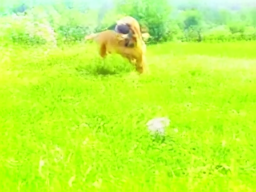

Frame 0006:


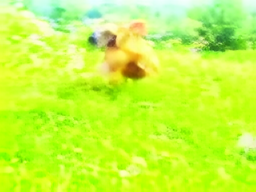

Frame 0012:


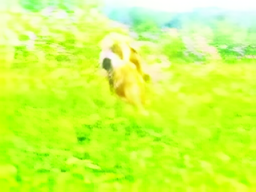

Frame 0018:


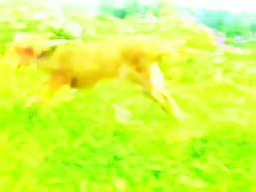

Frame 0024:


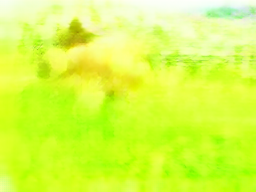

In [12]:
# Display sample frames
from IPython.display import display
import PIL.Image

sample_indices = [0, len(frames) // 4, len(frames) // 2, 3 * len(frames) // 4, len(frames) - 1]
for idx in sample_indices:
    print(f"Frame {idx:04d}:")
    display(frames[idx].resize((256, 192)))  # Thumbnail for display

In [13]:
# Save metadata
metadata = {
    "model": "Lightricks/LTX-2",
    "prompt": PROMPT,
    "resolution": f"{WIDTH}x{HEIGHT}",
    "num_frames": NUM_FRAMES,
    "num_steps": NUM_STEPS,
    "guidance_scale": 4.0,
    "max_sequence_length": 1024,
    "seed": SEED,
    "first_generation_time_s": first_gen_time,
    "text_encoder": f"Neuron Gemma3-12B (TP={TP_DEGREE})",
    "dit": f"Neuron LTX2 DiT 48 blocks (TP={TP_DEGREE})",
}

with open(os.path.join(OUTPUT_DIR, "metadata.json"), "w") as f:
    json.dump(metadata, f, indent=2)

print(f"\nFirst generation time (with warmup): {first_gen_time:.1f}s")
print(f"Output: {OUTPUT_DIR}")


First generation time (with warmup): 63.9s
Output: /home/ubuntu/ltx2_output/


## 9. Try Your Own Prompt (Warm Generation)

With models already loaded, this generation reflects steady-state performance without warmup overhead. Change the prompt below and re-run to generate a different video.

  0%|          | 0/8 [00:00<?, ?it/s]

Warm generation time: 21.5s
Frame 0:


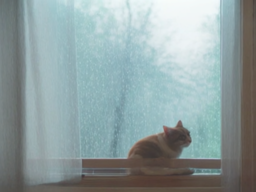

Frame 24:


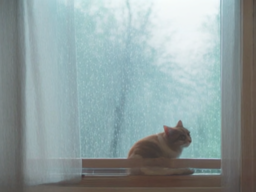

In [14]:
# Change this prompt to generate different content
my_prompt = "A cat sitting on a windowsill watches rain falling outside, with soft piano music playing."

generator = torch.Generator(device="cpu").manual_seed(123)

t0 = time.time()
output2 = pipe(
    prompt=my_prompt,
    height=HEIGHT,
    width=WIDTH,
    num_frames=NUM_FRAMES,
    num_inference_steps=NUM_STEPS,
    generator=generator,
    output_type="pil",
)
warm_gen_time = time.time() - t0
print(f"Warm generation time: {warm_gen_time:.1f}s")

# Display first and last frame
from IPython.display import display
frames2 = output2.frames[0]
print(f"Frame 0:")
display(frames2[0].resize((256, 192)))
print(f"Frame {len(frames2)-1}:")
display(frames2[-1].resize((256, 192)))